## **Producing Visualizations**

In [1]:
#Importing
import numpy as np
import pandas as pd

In [5]:
#2015-16 Data
#Prices
ugd_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2015-16).csv')
ugd_p = pd.pivot_table(ugd_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2015-16).csv')
ugd_x = pd.pivot_table(ugd_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd_x_long = ugd_x.stack().reset_index(name="Expenditure")
ugd_p_long = ugd_p0
ugd_c = ugd_x_long.merge(ugd_p_long, on=["j", "t", "m"], how="left")
ugd_c["Consumption"] = ugd_c["Expenditure"] / ugd_c["price"]
ugd_c = ugd_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z = pd.read_csv('Data Files/Uganda - Household Characteristics.csv')
ugd_z = ugd_z[ugd_z['t'] == '2015-16']
ugd_z = ugd_z.set_index(['i','t','m'])
ugd_z.fillna(0, inplace=True)
ugd_z.columns.name = 'k'

In [6]:
#2011-12 Data
#Prices
ugd3_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2011-12).csv')
ugd3_p0 = ugd3_p0[ugd3_p0["u"] == "Kg"]
ugd3_p = pd.pivot_table(ugd3_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd3_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2011-12).csv')
ugd3_x0['i'] = ugd3_x0['i'].astype(str)
ugd3_x = pd.pivot_table(ugd3_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd3_x_long = ugd3_x.stack().reset_index(name="Expenditure")
ugd3_p_long = ugd3_p0
ugd3_c = ugd3_x_long.merge(ugd3_p_long, on=["j", "t", "m"], how="left")
ugd3_c["Consumption"] = ugd3_c["Expenditure"] / ugd3_c["price"]
ugd3_c = ugd3_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z0 = pd.read_csv('Data Files/Uganda - Household Characteristics.csv')
ugd3_z = ugd_z0[ugd_z0['t'] == '2011-12']
ugd3_z = ugd3_z.set_index(['i','t','m'])
ugd3_z.columns.name = 'k'
ugd3_z.fillna(0, inplace=True)

In [7]:
#2009-10 Data
#Prices
ugd2_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2009-10).csv')
ugd2_p0 = ugd2_p0[ugd2_p0["u"] == "Kg"]
ugd2_p = pd.pivot_table(ugd2_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd2_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2009-10).csv')
ugd2_x0['i'] = ugd2_x0['i'].astype(str)
ugd2_x = pd.pivot_table(ugd2_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd2_x_long = ugd2_x.stack().reset_index(name="Expenditure")  # Ensure values are in a column
ugd2_p_long = ugd2_p0
ugd2_c = ugd2_x_long.merge(ugd2_p_long, on=["j", "t", "m"], how="left")
ugd2_c["Consumption"] = ugd2_c["Expenditure"] / ugd2_c["price"]
ugd2_c = ugd2_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z0 = pd.read_csv('Data Files/Uganda - Household Characteristics.csv')
ugd2_z = ugd_z0[ugd_z0['t'] == '2009-10']
ugd2_z = ugd2_z.set_index(['i','t','m'])
ugd2_z.columns.name = 'k'
ugd2_z.fillna(0, inplace=True)

In [8]:
#FCT and RDI
#FCT
ugd_fct = pd.read_csv('Data Files/Uganda - FCT.csv')
ugd_fct = ugd_fct.rename(columns={"index":"j"}).set_index(["j"])
ugd_fct.columns.name = 'n'
#RDI
ugd_rdi = pd.read_csv('Data Files/Uganda - RDA.csv')
ugd_rdi = ugd_rdi.set_index(["n"])
ugd_rdi.columns.name = 'k'

### Average Expenditures

In [12]:
#15-16 Avg Expenditure
row_sums1 = ugd_x.sum(axis=1)
mean_row_sum1 = row_sums1.mean()
#09-10 Avg Expenditure
row_sums2 = ugd2_x.sum(axis=1)
mean_row_sum2 = row_sums2.mean()
#11-12 Avg Expenditure
row_sums3 = ugd3_x.sum(axis=1)
mean_row_sum3 = row_sums3.mean()

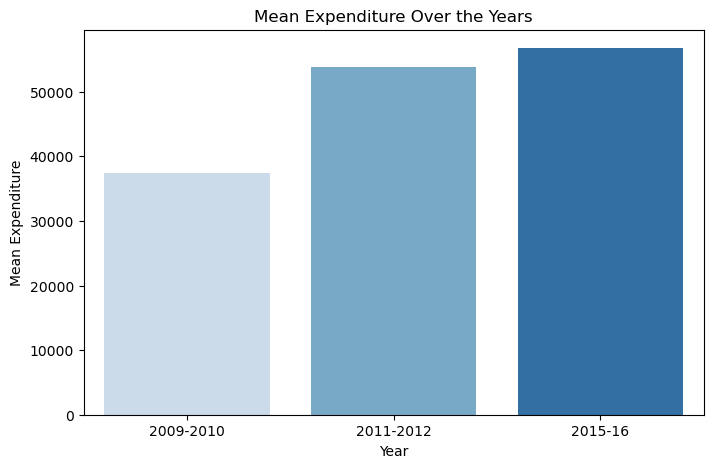

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting
data = {'Year': ['2009-2010', '2011-2012', '2015-16'], 
    'Mean Expenditure': [mean_row_sum2, mean_row_sum3, mean_row_sum1]
       }

avgexp_df = pd.DataFrame(data)

# Plot the bar graph
plt.figure(figsize=(8, 5))
sns.barplot(x='Year', y='Mean Expenditure', data=avgexp_df, hue='Year', palette='Blues', legend=False)

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Mean Expenditure')
plt.title('Mean Expenditure Over the Years')

# Show the plot
plt.show()

### Most Consumed Foods

In [16]:
#15-16 Consumption by food, descending
column_sums1 = ugd_c.sum()
sorted_sums1 = column_sums1.sort_values(ascending=False)
#09-10 Consumption by food, descending
column_sums2 = ugd2_c.sum()
sorted_sums2 = column_sums2.sort_values(ascending=False)
#11-12 Consumption by food, descending
column_sums3 = ugd3_c.sum()
sorted_sums3 = column_sums3.sort_values(ascending=False)

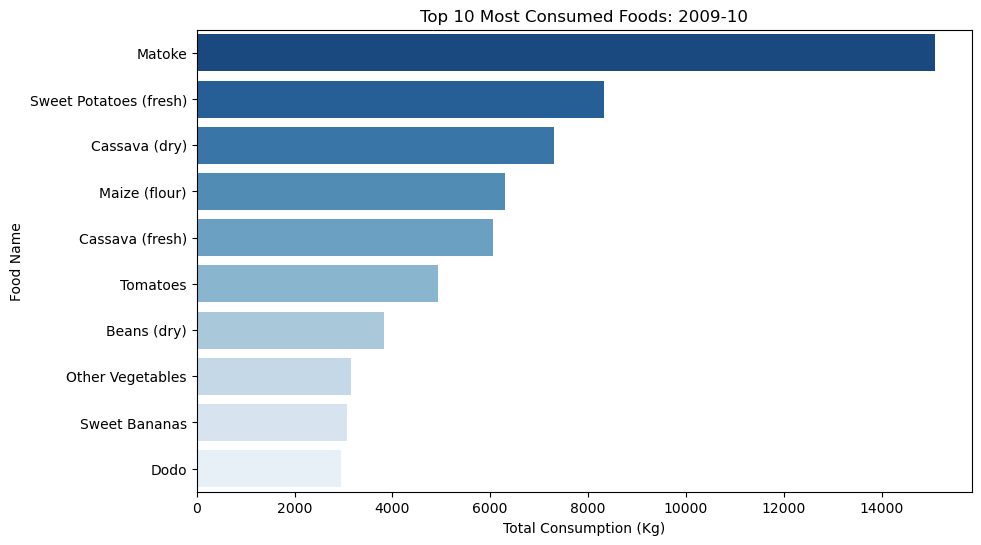

In [23]:
# Select the top 10 most consumed foods
top_10_foods2 = sorted_sums2.nlargest(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_foods1.values, y=top_10_foods2.index, hue=top_10_foods2.index, palette="Blues_r", legend=False)

# Labels and title
plt.xlabel("Total Consumption (Kg)")
plt.ylabel("Food Name")
plt.title("Top 10 Most Consumed Foods: 2009-10")

plt.show()

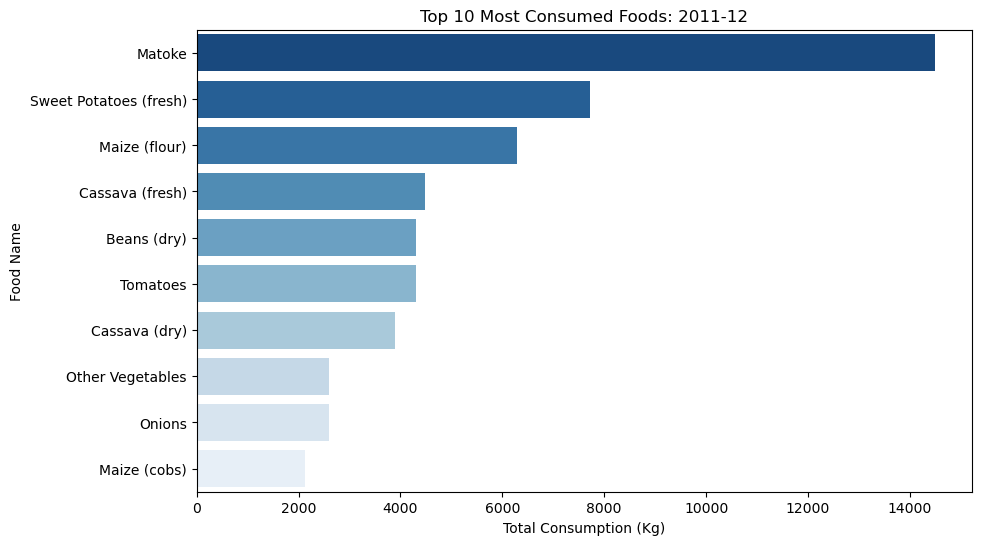

In [24]:
# Select the top 10 most consumed foods
top_10_foods3 = sorted_sums3.nlargest(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_foods3.values, y=top_10_foods3.index, hue=top_10_foods3.index, palette="Blues_r", legend=False)

# Labels and title
plt.xlabel("Total Consumption (Kg)")
plt.ylabel("Food Name")
plt.title("Top 10 Most Consumed Foods: 2011-12")

plt.show()

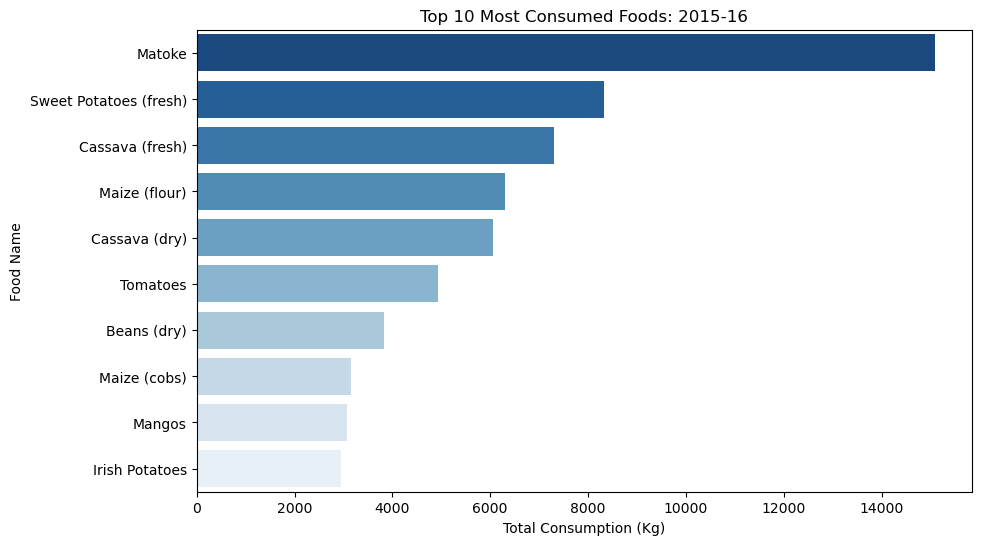

In [22]:
# Select the top 10 most consumed foods
top_10_foods1 = sorted_sums1.nlargest(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_foods1.values, y=top_10_foods1.index, hue=top_10_foods1.index, palette="Blues_r", legend=False)

# Labels and title
plt.xlabel("Total Consumption (Kg)")
plt.ylabel("Food Name")
plt.title("Top 10 Most Consumed Foods: 2015-16")

plt.show()